<a href="https://colab.research.google.com/github/richiv4r3-crypto/MineriaDeDatos/blob/main/Liga_MX_jornada_16_Predicci%C3%B3n_utilizando_Random_Forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predicción de Resultados de Liga MX con Random Forest

Libreta didáctica para Google Colab



## Objetivo

Aplicar Machine Learning supervisado para predecir resultados de partidos de Liga MX usando Random Forest.

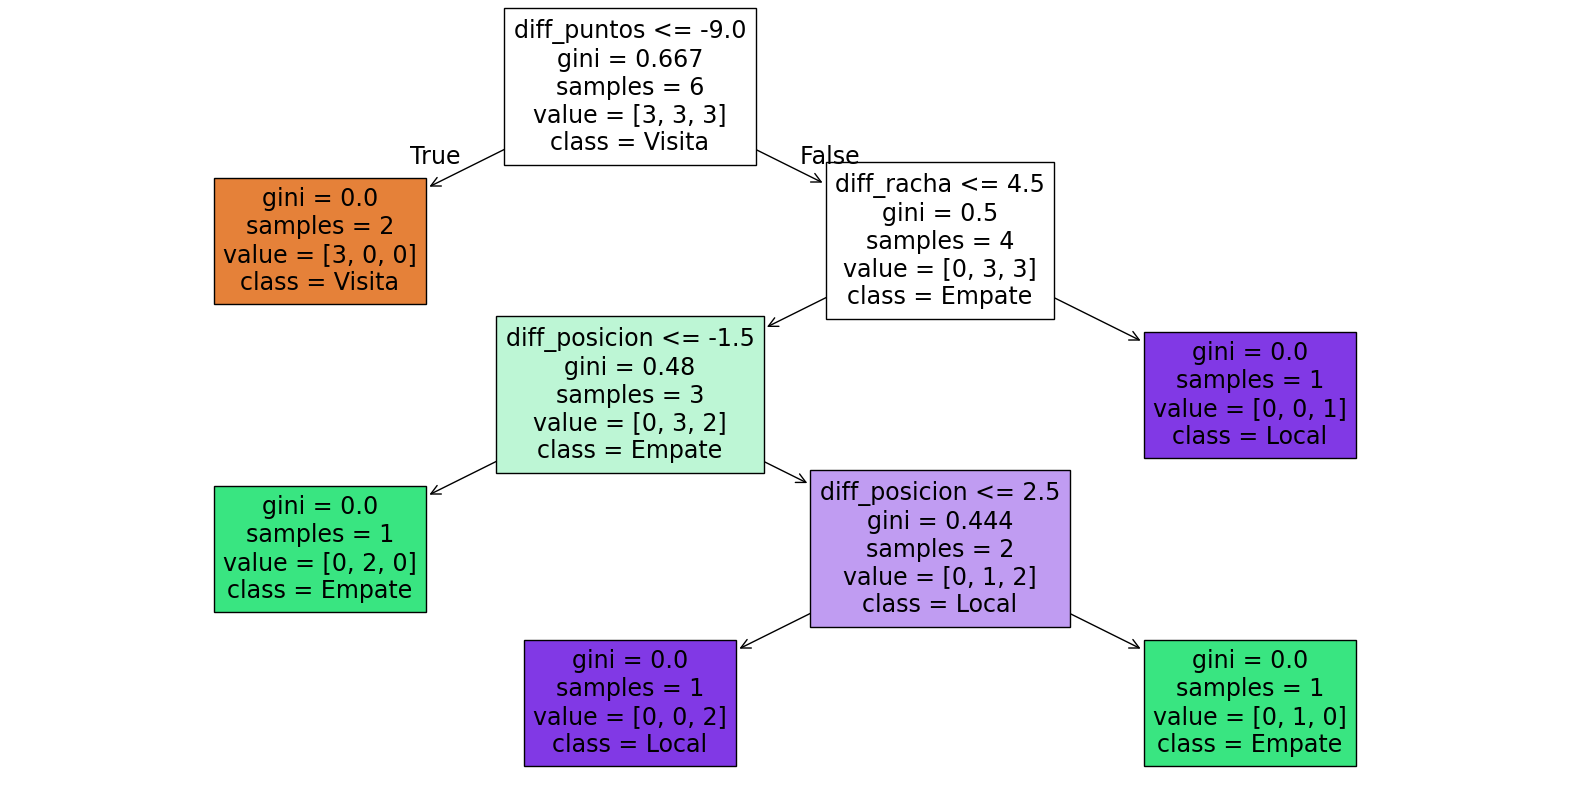

In [7]:
import pandas as pd
import numpy as np

## Cargar dataset
df = pd.read_csv('dataset_liga_mx_jornadas_13_14_15_base.csv')
df.head()

## Selección de features
features = ['diff_puntos','diff_racha','diff_posicion']
X = df[features]
y = df['resultado']

## Entrenamiento del Random Forest
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=300, max_depth=5, random_state=42)
rf.fit(X, y)

## Importancia de variables
importances = pd.Series(rf.feature_importances_, index=features)
importances.sort_values(ascending=False)

## Visualización de un árbol
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
plt.figure(figsize=(20,10))
plot_tree(rf.estimators_[0], feature_names=features, class_names=['Visita','Empate','Local'], filled=True)
plt.show()

##Entrenamiento del modelo Random Forest







In [8]:
features = ['diff_puntos', 'diff_racha', 'diff_posicion']
X = df[features]
y = df['resultado']

rf = RandomForestClassifier(n_estimators=300, max_depth=5, random_state=42)
rf.fit(X, y)

# Importancia de variables
importances = pd.Series(rf.feature_importances_, index=features)
print("Importancia de features:")
print(importances.sort_values(ascending=False))

Importancia de features:
diff_puntos      0.364355
diff_posicion    0.336094
diff_racha       0.299551
dtype: float64


##Estado de los equipos después de la jornada 15


In [9]:
# Se crea un diccionario con los valores previos a la jornada 15
equipos = {}
for idx, row in df[df['jornada']==15].iterrows():
    # Equipo local
    equipos[row['equipo_local']] = {
        'puntos': row['local_puntos'],
        'racha': row['local_racha'],
        'posicion': row['local_posicion']
    }
    # Equipo visitante
    equipos[row['equipo_visita']] = {
        'puntos': row['visita_puntos'],
        'racha': row['visita_racha'],
        'posicion': row['visita_posicion']
    }

# Aplicamos los resultados de la jornada 15 para actualizar puntos y rachas
for idx, row in df[df['jornada']==15].iterrows():
    local = row['equipo_local']
    visit = row['equipo_visita']
    res = row['resultado']

    if res == 2:  # Gana local
        equipos[local]['puntos'] += 3
        equipos[local]['racha'] = equipos[local]['racha'] + 1
        equipos[visit]['racha'] = 0
    elif res == 1:  # Empate
        equipos[local]['puntos'] += 1
        equipos[visit]['puntos'] += 1
        equipos[local]['racha'] = equipos[local]['racha'] + 1
        equipos[visit]['racha'] = equipos[visit]['racha'] + 1
    else:  # res == 0, gana visitante
        equipos[visit]['puntos'] += 3
        equipos[visit]['racha'] = equipos[visit]['racha'] + 1
        equipos[local]['racha'] = 0

# Recalculamos posiciones después de la jornada 15 (orden por puntos descendente)
equipos_ordenados = sorted(equipos.items(), key=lambda x: x[1]['puntos'], reverse=True)
posicion = 1
for equipo, stats in equipos_ordenados:
    stats['posicion'] = posicion
    posicion += 1

# Mostrar tabla final
df_estado = pd.DataFrame.from_dict(equipos, orient='index')
df_estado.sort_values('posicion', inplace=True)
print("Estado de los equipos después de la jornada 15:")
df_estado.head(10)

Estado de los equipos después de la jornada 15:


,puntos,racha,posicion
Chivas,37,10,1
Pachuca,34,10,2
Pumas,33,8,3
Cruz Azul,30,6,4
Toluca,27,0,5
León,25,10,6
América,25,7,7
Atlas,25,8,8
Tigres,22,5,9
Tijuana,20,5,10


##Partidos de la jornada 16


In [10]:
partidos_j16 = [
    ('Querétaro', 'Cruz Azul'),
    ('Pumas', 'FC Juárez'),
    ('Monterrey', 'Puebla'),
    ('León', 'América'),
    ('Atlas', 'Tigres'),
    ('Atlético San Luis', 'Santos'),
    ('Mazatlán', 'Toluca'),
    ('Necaxa', 'Chivas'),
    ('Tijuana', 'Pachuca')
]

datos_prediccion = []
for local, visit in partidos_j16:
    stats_local = equipos[local]
    stats_visit = equipos[visit]
    diff_puntos = stats_local['puntos'] - stats_visit['puntos']
    diff_racha = stats_local['racha'] - stats_visit['racha']
    diff_posicion = stats_local['posicion'] - stats_visit['posicion']
    datos_prediccion.append([diff_puntos, diff_racha, diff_posicion])

X_j16 = pd.DataFrame(datos_prediccion, columns=features)
print("Características para la jornada 16:")
X_j16

Características para la jornada 16:


,diff_puntos,diff_racha,diff_posicion
0,-13,-1,8
1,17,8,-10
2,2,0,-2
3,0,3,-1
4,3,3,-1
5,6,0,-4
6,-14,3,11
7,-19,-4,10
8,-14,-5,8


##Predicción de resultados


In [11]:
predicciones = rf.predict(X_j16)
# Mapeo de números a resultados
resultado_map = {0: 'Gana visitante', 1: 'Empate', 2: 'Gana local'}

print("\nPredicciones Jornada 16")
for i, (local, visit) in enumerate(partidos_j16):
    pred = predicciones[i]
    print(f"{local} vs {visit}: {resultado_map[pred]}")


Predicciones Jornada 16
Querétaro vs Cruz Azul: Gana visitante
Pumas vs FC Juárez: Gana local
Monterrey vs Puebla: Empate
León vs América: Empate
Atlas vs Tigres: Empate
Atlético San Luis vs Santos: Empate
Mazatlán vs Toluca: Gana local
Necaxa vs Chivas: Gana visitante
Tijuana vs Pachuca: Gana visitante
